In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Load your data
df = pd.read_csv('C:/Users/DELL/Downloads/Legal Case/processed_data\legal_cases_complete22.csv')

print("=" * 70)
print("LEGAL CORPUS ANALYSIS REPORT")
print("=" * 70)
print(f"\n📊 Dataset Overview:")
print(f"   Total Cases: {len(df):,}")
print(f"   Sources: {df['Source_Folder'].nunique()}")
print(f"   Date Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"   Courts: {df['Court'].nunique()}")
print(f"\n📝 Text Statistics:")
print(f"   Avg Text Length: {df['Case_Text_Full_Length'].mean():.0f} chars")
print(f"   Max Text Length: {df['Case_Text_Full_Length'].max():,} chars")
print(f"   Min Text Length: {df['Case_Text_Full_Length'].min():,} chars")
print(f"\n📚 Citation Statistics:")
print(f"   Total Citations: {df['Num_Citations'].sum():,}")
print(f"   Avg Citations/Case: {df['Num_Citations'].mean():.2f}")
print(f"   Cases with Citations: {(df['Num_Citations'] > 0).sum():,} ({(df['Num_Citations'] > 0).sum()/len(df)*100:.1f}%)")

LEGAL CORPUS ANALYSIS REPORT

📊 Dataset Overview:
   Total Cases: 18,897
   Sources: 83
   Date Range: 1778 - 2019
   Courts: 36

📝 Text Statistics:
   Avg Text Length: 5089 chars
   Max Text Length: 266,325 chars
   Min Text Length: 103 chars

📚 Citation Statistics:
   Total Citations: 83,541
   Avg Citations/Case: 4.42
   Cases with Citations: 18,897 (100.0%)



CASE TYPE DISTRIBUTION
Civil Procedure                      5826 ( 30.8%) ███████████████
Criminal Law                         4966 ( 26.3%) █████████████
Contract Law - Debt                  2666 ( 14.1%) ███████
Property Law - Ejectment             2049 ( 10.8%) █████
Torts                                2013 ( 10.7%) █████
Unclassified                          928 (  4.9%) ██
Torts - Defamation                    238 (  1.3%) 
Property Law - Execution Sale         211 (  1.1%) 


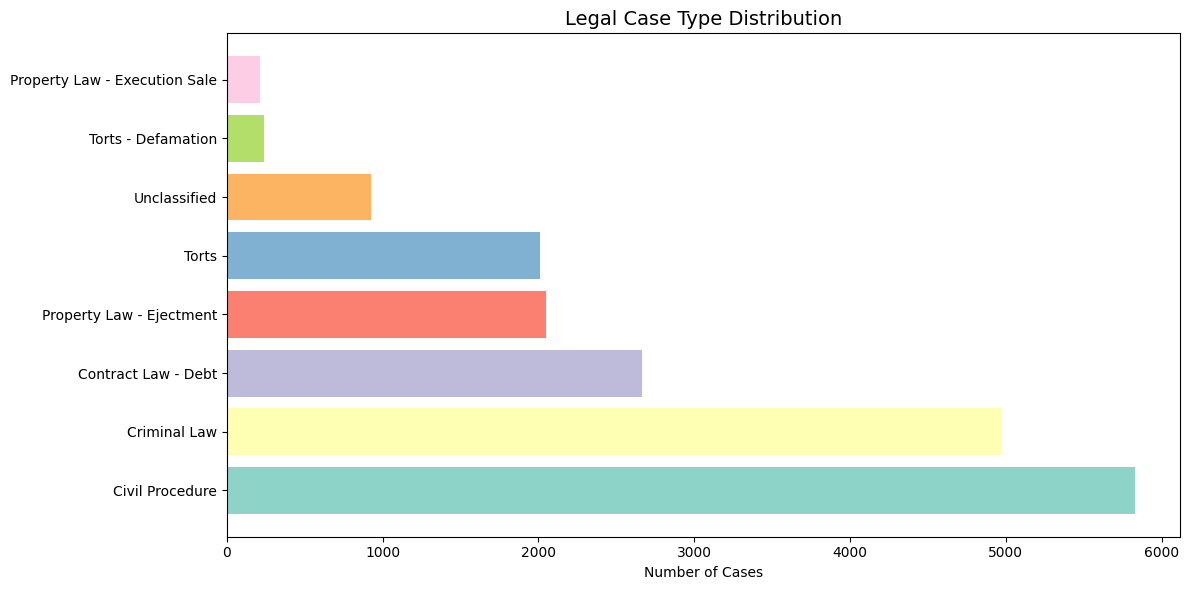

In [2]:
# Case type distribution
print("\n" + "=" * 70)
print("CASE TYPE DISTRIBUTION")
print("=" * 70)

case_type_dist = df['Case_Type'].value_counts()
for ct, count in case_type_dist.items():
    pct = count/len(df)*100
    bar = "█" * int(pct/2)
    print(f"{ct:<35} {count:>5} ({pct:>5.1f}%) {bar}")

# Visualize
plt.figure(figsize=(12, 6))
colors = plt.cm.Set3(range(len(case_type_dist)))
plt.barh(range(len(case_type_dist)), case_type_dist.values, color=colors)
plt.yticks(range(len(case_type_dist)), case_type_dist.index)
plt.xlabel('Number of Cases')
plt.title('Legal Case Type Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('case_type_distribution.png', dpi=150)
plt.show()

In [3]:
# Verdict distribution
print("\n" + "=" * 70)
print("VERDICT DISTRIBUTION")
print("=" * 70)

verdict_dist = df['Verdict'].value_counts()
for v, count in verdict_dist.head(15).items():
    pct = count/len(df)*100
    print(f"{v:<35} {count:>5} ({pct:>5.1f}%)")

# Known vs Unknown verdicts
known_verdicts = df[df['Verdict'] != 'Verdict Unknown']
unknown_verdicts = df[df['Verdict'] == 'Verdict Unknown']

print(f"\n✅ Known Verdicts: {len(known_verdicts):,} ({len(known_verdicts)/len(df)*100:.1f}%)")
print(f"❌ Unknown Verdicts: {len(unknown_verdicts):,} ({len(unknown_verdicts)/len(df)*100:.1f}%)")

# Outcome analysis for known verdicts
print("\n⚖️ Case Outcomes (Known Verdicts Only):")
outcomes = known_verdicts['Verdict'].str.contains('AFFIRMED|REVERSED|SET ASIDE')
affirmed = known_verdicts['Verdict'].str.contains('AFFIRMED').sum()
reversed_count = known_verdicts['Verdict'].str.contains('REVERSED').sum()
set_aside = known_verdicts['Verdict'].str.contains('SET ASIDE').sum()

print(f"   Affirmed: {affirmed} ({affirmed/len(known_verdicts)*100:.1f}%)")
print(f"   Reversed: {reversed_count} ({reversed_count/len(known_verdicts)*100:.1f}%)")
print(f"   Set Aside: {set_aside} ({set_aside/len(known_verdicts)*100:.1f}%)")


VERDICT DISTRIBUTION
Judgment AFFIRMED                    3984 ( 21.1%)
Judgment REVERSED                    2128 ( 11.3%)
Verdict Unknown                      1896 ( 10.0%)
Denied                               1869 (  9.9%)
Claim Disallowed                     1009 (  5.3%)
Remanded                              990 (  5.2%)
Sustained                             682 (  3.6%)
Per Curiam: Judgment REVERSED         680 (  3.6%)
Per Curiam: Judgment AFFIRMED         507 (  2.7%)
Granted                               390 (  2.1%)
Legal Ruling (No Final Judgment)      340 (  1.8%)
Overruled                             272 (  1.4%)
Case Dismissed                        204 (  1.1%)
Dismissed                             173 (  0.9%)
Demurrer OVERRULED                    166 (  0.9%)

✅ Known Verdicts: 17,001 (90.0%)
❌ Unknown Verdicts: 1,896 (10.0%)

⚖️ Case Outcomes (Known Verdicts Only):
   Affirmed: 4528 (26.6%)
   Reversed: 2880 (16.9%)
   Set Aside: 5 (0.0%)


In [4]:
# Sub-type distribution
print("\n" + "=" * 70)
print("SUB-TYPE DISTRIBUTION")
print("=" * 70)

subtype_dist = df['Sub_Type'].value_counts()
for st, count in subtype_dist.head(15).items():
    pct = count/len(df)*100
    print(f"{st:<25} {count:>5} ({pct:>5.1f}%)")

# Cross-tabulation: Case Type vs Sub-Type
print("\n" + "=" * 70)
print("CASE TYPE × SUB-TYPE MATRIX")
print("=" * 70)

cross_tab = pd.crosstab(df['Case_Type'], df['Sub_Type'], margins=True)
print(cross_tab)


SUB-TYPE DISTRIBUTION
Appeal                     3935 ( 20.8%)
General Criminal           3773 ( 20.0%)
Negligence                 1380 (  7.3%)
Demurrer                   1316 (  7.0%)
Title Dispute              1154 (  6.1%)
Promissory Note             955 (  5.1%)
Unclassified                925 (  4.9%)
Bond                        818 (  4.3%)
General Torts               473 (  2.5%)
Debt Collection             407 (  2.2%)
Homicide                    407 (  2.2%)
Mortgage Foreclosure        389 (  2.1%)
Larceny                     366 (  1.9%)
Pleading                    347 (  1.8%)
General Contract            294 (  1.6%)

CASE TYPE × SUB-TYPE MATRIX
Sub_Type                       Adverse Possession  Affray  Appeal  \
Case_Type                                                           
Civil Procedure                                 0       0    3935   
Contract Law - Debt                             0       0       0   
Criminal Law                                    0       2

In [5]:
# Citation analysis
print("\n" + "=" * 70)
print("CITATION NETWORK ANALYSIS")
print("=" * 70)

# Cases with most citations
top_cited = df.nlargest(10, 'Num_Citations')[['Case_ID', 'Case_Name', 'Num_Citations', 'Case_Type']]
print("Top 10 Most Cited Cases:")
for i, row in top_cited.iterrows():
    print(f"   {row['Case_ID']}: {row['Case_Name'][:50]}... ({row['Num_Citations']} citations)")

# Citation patterns by case type
print("\nAverage Citations by Case Type:")
citations_by_type = df.groupby('Case_Type')['Num_Citations'].mean().sort_values(ascending=False)
for ct, avg_cite in citations_by_type.head(10).items():
    print(f"   {ct:<30} {avg_cite:.2f} avg citations")

# Extract all unique cited cases
all_citations = []
for cites in df['Legal_Citations'].dropna():
    if isinstance(cites, str):
        all_citations.extend(cites.split('; '))

unique_citations = set(all_citations)
print(f"\n📚 Unique Citations in Corpus: {len(unique_citations):,}")


CITATION NETWORK ANALYSIS
Top 10 Most Cited Cases:
   465: 0465-01... (344 citations)
   230: 0230-01... (288 citations)
   83: 0083-01... (234 citations)
   353: 0353-01... (203 citations)
   777: 0777-01... (201 citations)
   128: 0128-01... (193 citations)
   569: 0569-01... (187 citations)
   489: 0489-01... (186 citations)
   804: 0804-01... (175 citations)
   618: 0618-01... (173 citations)

Average Citations by Case Type:
   Torts - Defamation             12.73 avg citations
   Criminal Law                   5.46 avg citations
   Contract Law - Debt            4.39 avg citations
   Civil Procedure                4.37 avg citations
   Property Law - Ejectment       3.80 avg citations
   Torts                          3.40 avg citations
   Property Law - Execution Sale  2.13 avg citations
   Unclassified                   1.20 avg citations

📚 Unique Citations in Corpus: 48,327


In [6]:
print("Initial Shape:", df.shape)
print(df.head())

# ============================================================
# 3. BASIC CLEANING
# ============================================================

# Check duplicates
print("Duplicates check:", df.duplicated().sum())

# Check missing values
print("Missing values check:\n", df.isna().sum())


Initial Shape: (18897, 16)
   Case_ID Case_Name Source_Folder  Year                       Court  \
0      294   0294-01       fil3212  1959  Connecticut Superior Court   
1      170   0170-01       fil3212  1958  Connecticut Superior Court   
2       88   0088-01       fil3212  1958  Connecticut Superior Court   
3       55   0055-01       fil3212  1958  Connecticut Superior Court   
4      312   0312-01       fil3212  1959  Connecticut Superior Court   

                                           Case_Text  Case_Text_Full_Length  \
0  State ex rel. Nicholas Kenney v. George Ranslo...                  10720   
1  Frank V. Feroleto v. Dolan Steel Company, Inc....                   8039   
2  Americo Camerota et al. v. Bronislawa Wisniews...                   5867   
3  Ralph H. Edson v. The Griffin Hospital et al. ...                  16580   
4  Esther Kolodney, Administratrix (Estate of Sam...                  10019   

                  Verdict                 Case_Type              

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18897 entries, 0 to 18896
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Case_ID                18897 non-null  int64 
 1   Case_Name              18897 non-null  object
 2   Source_Folder          18897 non-null  object
 3   Year                   18897 non-null  int64 
 4   Court                  18897 non-null  object
 5   Case_Text              18897 non-null  object
 6   Case_Text_Full_Length  18897 non-null  int64 
 7   Verdict                18897 non-null  object
 8   Case_Type              18897 non-null  object
 9   Sub_Type               18897 non-null  object
 10  Num_Citations          18897 non-null  int64 
 11  Legal_Citations        18897 non-null  object
 12  Decision_Date          18897 non-null  object
 13  Docket_Number          10614 non-null  object
 14  First_Page             18897 non-null  int64 
 15  Last_Page          

In [8]:
# ============================================================
# 4. CLEAN CASE TEXT (LEGAL NLP PREPROCESSING)
# ============================================================

def clean_legal_text(text):
    text = str(text).lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = text.strip()
    return text

df['Case_Text'] = df['Case_Text'].apply(clean_legal_text)

In [9]:
# ============================================================
# 5. PARSE + CLEAN + VALIDATE LEGAL CITATIONS (ONE CELL FINAL)
# ============================================================

import re

print("=== INITIAL DUPLICATE CHECKS ===")

# Ensure citation_list exists
df['citation_list'] = df['Legal_Citations'].apply(
    lambda x: [c.strip() for c in str(x).split(';') if c.strip()]
)

print("Duplicate Legal_Citations rows:", df['Legal_Citations'].duplicated().sum())

# Show duplicate citation_list rows (for inspection only)
dups = df[df['citation_list'].duplicated(keep=False)]
print("\nDuplicate citation_list rows:", len(dups))
print("Sample duplicate indices:", dups.index.tolist()[:10])

print("\nSample duplicate citation lists:")
print(dups[['Legal_Citations', 'citation_list']].head())

# ============================================================
# CLEAN + NORMALIZE + REMOVE DUPLICATES INSIDE EACH ROW
# ============================================================

def clean_and_deduplicate(citation_list):
    seen = set()
    cleaned = []
    
    for cite in citation_list:
        if not isinstance(cite, str):
            continue
        
        # normalize (VERY IMPORTANT FIX)
        cite = cite.lower().strip()
        cite = re.sub(r'\s+', ' ', cite)
        
        # remove duplicates inside row
        if cite and cite not in seen:
            seen.add(cite)
            cleaned.append(cite)
    
    return cleaned

# Apply cleaning
df['citation_list'] = df['citation_list'].apply(clean_and_deduplicate)

# ============================================================
# POST-CLEANING UPDATES
# ============================================================

df['num_citations_parsed'] = df['citation_list'].apply(len)

df['Legal_Citations_clean'] = df['citation_list'].apply(
    lambda x: "; ".join(x)
)

# ============================================================
# FINAL VALIDATION (VERY IMPORTANT)
# ============================================================

print("\n=== AFTER CLEANING ===")

# Check internal duplicates (must be ZERO)
internal_dup = df['citation_list'].apply(lambda x: len(x) != len(set(x)))
print("Rows still having internal duplicates:", internal_dup.sum())

# Dataset-level stats
all_citations = [c for row in df['citation_list'] for c in row]

print("\nTotal citations:", len(all_citations))
print("Unique citations:", len(set(all_citations)))
print("Duplicate ratio:", round(1 - len(set(all_citations)) / len(all_citations), 4))

print("\nCitation statistics:")
print(df['num_citations_parsed'].describe())

print("\nSample cleaned citations:")
print(df['citation_list'].head())

print("\n✔ CITATION CLEANING COMPLETED SUCCESSFULLY")

=== INITIAL DUPLICATE CHECKS ===
Duplicate Legal_Citations rows: 1491

Duplicate citation_list rows: 2405
Sample duplicate indices: [111, 116, 170, 181, 196, 255, 295, 307, 323, 337]

Sample duplicate citation lists:
    Legal_Citations     citation_list
111  10 Ky. Op. 329  [10 Ky. Op. 329]
116  10 Ky. Op. 757  [10 Ky. Op. 757]
170  10 Ky. Op. 757  [10 Ky. Op. 757]
181  10 Ky. Op. 682  [10 Ky. Op. 682]
196  10 Ky. Op. 925  [10 Ky. Op. 925]

=== AFTER CLEANING ===
Rows still having internal duplicates: 0

Total citations: 63257
Unique citations: 48327
Duplicate ratio: 0.236

Citation statistics:
count    18897.000000
mean         3.347463
std          4.568850
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         20.000000
Name: num_citations_parsed, dtype: float64

Sample cleaned citations:
0    [113 ill. 137, 121 conn. 237, 121 ind. 206, 12...
1    [118 conn. 190, 122 conn. 185, 15 f.r.d. 44, 1...
2    [108 conn. 683, 109 mass. 419, 129 u

In [10]:
# ============================================================
# ONE-CELL: VERDICT UNIQUE VALUES + LEGAL-AWARE ANALYSIS
# ============================================================

print("=== UNIQUE VERDICT TEXTS ===\n")
unique_verdicts = df['Verdict'].unique()
for v in unique_verdicts:
    print(v)

print("\nTotal unique verdict forms:", len(unique_verdicts))

=== UNIQUE VERDICT TEXTS ===

Judgment for Defendant
Award Denied
Demurrer SUSTAINED
Verdict Unknown
Denied
Verdict for Plaintiffs
Sustained
Judgment AFFIRMED
Legal Ruling (No Final Judgment)
Judgment for Plaintiff
Remanded
Granted
Overruled
Judgment Entered (No Costs)
Demurrer OVERRULED
Void
Case Dismissed
Decree for Plaintiff
Award Granted ($46,000)
Judgment for Defendant - No Desertion
Judgment for Defendant(s)
Injunction Granted
Trust Construction - Ruling Issued
Judgment REVERSED
Appeal DISMISSED
Verdict: GUILTY
Judgment Void
Award Granted ($15,000)
Set Aside
Sale Void
Award Granted ($38.09)
Judgment for Defendants
Judgment REVERSED on Appeal
Dismissed
Declaratory Judgment - Regulation Invalid
Settlement - Award Recommended ($54,153.93)
Damages Awarded to Plaintiff
Judgment for Plaintiff ($1,549)
Will Construction - Ruling Issued
Temporary Injunction Granted
Award Granted ($108)
Verdict: NOT GUILTY
Judgment AFFIRMED in part, REVERSED in part
Instruction GIVEN
Proceedings Set Aside

In [11]:
"""
Legal Verdict Label Engineering Pipeline
=========================================
Converts raw noisy judicial verdict prose into 4 clean ML classes.

Four classes:
    AFFIRMED   — judgment affirmed (fully or partially)
    REVERSED   — judgment reversed, set aside, or vacated
    DISMISSED  — case dismissed or recovery barred
    NON_FINAL  — procedural, interlocutory, remanded, or unresolved

Pipeline stages:
    1. OCR cleaning       — fix glyph errors, fused words, stray punctuation
    2. Leakage guard      — isolate label columns from feature columns
    3. Keyword extraction — regex rules against ALL 118 observed verdict forms
    4. Four-class mapping — keyword → one of four canonical labels
    5. Integrity checks   — zero NaN, zero leakage, full coverage audit
"""

import re
import pandas as pd
import numpy as np
from collections import Counter
from typing import Tuple, Dict, List


# ═══════════════════════════════════════════════════════════════════════════════
# CONSTANTS
# ═══════════════════════════════════════════════════════════════════════════════

FOUR_CLASSES = ['AFFIRMED', 'REVERSED', 'DISMISSED', 'NON_FINAL']

# Columns that touch verdict text — ALL must be excluded from X at train time.
# Add any new derived columns here as you create them.
LEAKAGE_COLUMNS = [
    'verdict_text',
    'verdict_clean',
    'keyword',
    'verdict_category',      # original 8-class label
    'outcome_simple',        # any prior simplified label
    'four_class_label',      # the target we are building
]


# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — OCR CLEANING
# Built directly from the 118 observed verdict forms in your dataset.
# ═══════════════════════════════════════════════════════════════════════════════

# Each tuple: (regex_pattern, replacement)
# Applied in ORDER — earlier rules run first.
OCR_FIXES: List[Tuple[str, str]] = [

    # ── Fused-word splits ─────────────────────────────────────────────────────
    # "Judgmentis" → "Judgment is"
    # "Thejudgmentis" → "The judgment is"
    (r'(?<=[a-zA-Z])(?=[A-Z][a-z])',        r' '),

    # ── Stray punctuation acting as letters ──────────────────────────────────
    # "Judgment'Is-" → "Judgment Is"
    # "The Judgment.Is" → "The Judgment Is"
    # "The' Judgment" → "The Judgment"
    (r"[''`´]",                              r''),
    (r'[.\-]+(?=\s*(?:REVERSED|AFFIRMED|IS|ARE)\b)', r' '),

    # ── Specific OCR letter substitutions seen in your data ──────────────────
    # "Judgment Js REVERSED" → "Judgment Is REVERSED"  (J→I misread)
    (r'\bJs\b',                              r'Is'),
    # ":Udoment" → "Judgment"  (U→J, d→dg misread)
    (r':Udoment\b',                          r'Judgment'),
    # "J Udgment" → "Judgment"  (split glyph)
    (r'\bJ\s+Udgment\b',                     r'Judgment'),
    # "Deci'Ee" → "Decree"
    (r"\bDeci'Ee\b",                         r'Decree'),
    # "Mrsj" → "Mrs."  (j is ink bleed from next character)
    (r'\bMrsj\b',                            r'Mrs.'),
    # "Tíre" → "The"  (accented i, OCR misread)
    (r'\bTíre\b',                            r'The'),
    # "Sb Much" → "So Much"
    (r'\bSb\b',                              r'So'),
    # "Pro»" → "Pro-"  (guillemet misread as s)
    (r'»',                                   r'-'),
    # "¡" stray inverted exclamation mark
    (r'[¡]',                                 r' '),
    # "/That" → "That"  (slash artifact before word)
    (r'^/\s*',                               r''),
    (r'\s/\s*',                              r' '),
    # "•" bullet artifact
    (r'[•]',                                 r' '),
    # "&C." → "etc."  abbreviation normalisation
    (r'&C\.?',                               r'etc.'),

    # ── Spacing cleanup ───────────────────────────────────────────────────────
    (r'\s{2,}',                              r' '),
    (r"^\s+|\s+$",                           r''),
]


def clean_ocr(text: str) -> str:
    """
    Apply all OCR fixes and return an UPPERCASED, whitespace-normalised string
    ready for keyword extraction.

    The result is ONLY used internally to mine the label.
    It is never used as a model input feature.

    Examples
    --------
    >>> clean_ocr("Per Curiam: The Judgment Js REVERSED")
    'PER CURIAM: THE JUDGMENT IS REVERSED'

    >>> clean_ocr("Per Curiam: —The :Udoment Is REVERSED")
    'PER CURIAM: THE JUDGMENT IS REVERSED'

    >>> clean_ocr("Per Curiam: The Judgment'Is- REVERSED")
    'PER CURIAM: THE JUDGMENT IS REVERSED'
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    t = text.strip()
    for pattern, replacement in OCR_FIXES:
        t = re.sub(pattern, replacement, t)

    # Final: collapse whitespace, uppercase for uniform regex matching
    return re.sub(r'\s+', ' ', t).strip().upper()


# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — KEYWORD EXTRACTION
# Rules built against ALL 118 observed verdict surface forms.
# Order is critical: most-specific patterns before most-general.
# ═══════════════════════════════════════════════════════════════════════════════

# Each tuple: (regex_pattern, canonical_keyword)
# First match wins. Keep specific patterns above general ones.
KEYWORD_RULES: List[Tuple[str, str]] = [

    # ── Partial rulings  (MUST precede plain AFFIRMED / REVERSED) ────────────
    # "Judgment AFFIRMED in part, REVERSED in part"
    (r'\bAFFIRMED\b.{0,60}\bIN\s+PART\b'
     r'|\bIN\s+PART\b.{0,60}\bAFFIRMED\b',           'AFFIRMED_IN_PART'),
    (r'\bREVERSED\b.{0,60}\bIN\s+PART\b'
     r'|\bIN\s+PART\b.{0,60}\bREVERSED\b',           'REVERSED_IN_PART'),

    # ── Cost-only / partial reversals (common in your data) ──────────────────
    # "The Judgment As To The Costs Is REVERSED"
    # "That Part Of The Judgment Which Is Against The Defendant For Costs Is REVERSED"
    (r'\b(AS\s+TO\s+THE\s+COSTS?'
     r'|RESPECTING\s+THE\s+DOCKET'
     r'|FOR\s+COSTS?\s+IS\s+REVERSED'
     r'|AGAINST\s+THE\s+DEFENDANT\s+FOR\s+COSTS'
     r'|DISCHARGED\s+THE\s+DEFENDANTS\s+FROM\s+THE\s+COSTS'
     r'|GIVES\s+COSTS\s+TO\s+THE\s+PLAINTIFF)\b'
     r'.{0,80}\bREVERSED\b',                          'REVERSED_COSTS'),

    # ── SET ASIDE (equity reversal — must precede plain REVERSED) ────────────
    # "It Is Decreed That The Sale ... Be SET ASIDE"
    # "Set Aside"  (standalone)
    (r'\bSET\s+ASIDE\b',                             'SET_ASIDE'),

    # ── Arrest of judgment (a form of reversal) ───────────────────────────────
    # "Arrest of Judgment REVERSED"
    (r'\bARREST\s+OF\s+JUDGMENT\b',                  'ARREST_JUDGMENT'),

    # ── Plain terminal keywords ───────────────────────────────────────────────
    (r'\bAFFIRMED\b',                                'AFFIRMED'),
    (r'\bREVERSED\b',                                'REVERSED'),
    (r'\bDISMISSED\b',                               'DISMISSED'),
    (r'\bREMANDED\b',                                'REMANDED'),
    (r'\bQUASHED\b',                                 'QUASHED'),
    (r'\bOVERRULED\b',                               'OVERRULED'),
    (r'\bSUSTAINED\b',                               'SUSTAINED'),
    (r'\bDENIED\b',                                  'DENIED'),
    (r'\bGRANTED\b',                                 'GRANTED'),
    (r'\bDISSOLVED\b',                               'DISSOLVED'),  # Injunction DISSOLVED
    (r'\bREFUSED\b',                                 'REFUSED'),    # Instruction REFUSED
    (r'\bGIVEN\b',                                   'GIVEN'),      # Instruction GIVEN

    # ── Standalone single-word verdicts ──────────────────────────────────────
    # These appear as bare words in your data (no surrounding prose)
    (r'^\s*VOID\s*$',                                'VOID'),
    (r'\bJUDGMENT\s+VOID\b',                         'VOID'),
    (r'^\s*BARRED\s*$',                              'BARRED'),
    (r'\bRECOVERY\s+BARRED\b',                       'BARRED'),
    (r'^\s*OVERRULED\s*$',                           'OVERRULED'),
    (r'^\s*SUSTAINED\s*$',                           'SUSTAINED'),

    # ── Decree for complainant ────────────────────────────────────────────────
    # "Decree for Complainant" — equity win for plaintiff, equivalent to AFFIRMED
    (r'\bDECREE\s+FOR\s+COMPLAINANT\b',              'DECREE_COMPLAINANT'),

    # ── Plea outcomes ─────────────────────────────────────────────────────────
    # "Plea GOOD" / "Plea INSUFFICIENT"
    (r'\bPLEA\s+GOOD\b',                             'PLEA_GOOD'),
    (r'\bPLEA\s+INSUFFICIENT\b',                     'PLEA_INSUFFICIENT'),

    # ── Held / Error found ────────────────────────────────────────────────────
    # "Held: Error Found" — error found = judgment below is wrong = REVERSED
    (r'\bERROR\s+FOUND\b',                           'ERROR_FOUND'),

    # ── Legal ruling / no final judgment ─────────────────────────────────────
    # "Legal Ruling (No Final Judgment)"
    (r'NO\s+FINAL\s+JUDGMENT',                       'NO_FINAL_JUDGMENT'),

    # ── Criminal verdicts ─────────────────────────────────────────────────────
    # "Verdict: GUILTY" / "Found GUILTY"
    (r'\bGUILTY\b',                                  'GUILTY'),

    # ── Bill dismissed ────────────────────────────────────────────────────────
    # "Bill Dismissed" / "Case Dismissed"
    (r'\b(BILL|CASE)\s+DISMISSED\b',                 'DISMISSED'),

    # ── Appeal dismissed ──────────────────────────────────────────────────────
    (r'\bAPPEAL\s+DISMISSED\b',                      'APPEAL_DISMISSED'),
]


def extract_keyword(clean_text: str) -> str:
    """
    Scan OCR-cleaned (uppercased) verdict text for the first matching rule.

    Returns the canonical keyword string, or 'UNKNOWN' if nothing matches.
    UNKNOWN is mapped to NON_FINAL in KEYWORD_TO_FOUR_CLASS — never dropped.

    Parameters
    ----------
    clean_text : str
        Output of clean_ocr(). Must be uppercase.

    Returns
    -------
    str
        Canonical keyword, e.g. 'AFFIRMED', 'REVERSED_COSTS', 'UNKNOWN'.
    """
    for pattern, keyword in KEYWORD_RULES:
        if re.search(pattern, clean_text, re.IGNORECASE):
            return keyword
    return 'UNKNOWN'


# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — FOUR-CLASS MAPPING
# Every possible keyword maps to exactly one of the four classes.
# Nothing is dropped. Nothing produces NaN.
# ═══════════════════════════════════════════════════════════════════════════════

KEYWORD_TO_FOUR_CLASS: Dict[str, str] = {

    # ── AFFIRMED (class 1) ────────────────────────────────────────────────────
    'AFFIRMED':           'AFFIRMED',
    'AFFIRMED_IN_PART':   'AFFIRMED',   # partial affirmance is still an affirmance
    'DECREE_COMPLAINANT': 'AFFIRMED',   # equity win for plaintiff = affirmed outcome

    # ── REVERSED (class 2) ───────────────────────────────────────────────────
    'REVERSED':           'REVERSED',
    'REVERSED_IN_PART':   'REVERSED',   # partial reversal is still a reversal
    'REVERSED_COSTS':     'REVERSED',   # cost-only reversal is a reversal
    'SET_ASIDE':          'REVERSED',   # equity equivalent of reversal
    'ARREST_JUDGMENT':    'REVERSED',   # arresting judgment = reversing it
    'ERROR_FOUND':        'REVERSED',   # error found below = judgment reversed

    # ── DISMISSED (class 3) ──────────────────────────────────────────────────
    'DISMISSED':          'DISMISSED',
    'APPEAL_DISMISSED':   'DISMISSED',  # appeal dismissed = case ends
    'BARRED':             'DISMISSED',  # recovery barred = functionally dismissed

    # ── NON_FINAL (class 4) — procedural, interlocutory, unresolved ──────────
    'REMANDED':           'NON_FINAL',  # sends back for further proceedings
    'QUASHED':            'NON_FINAL',  # quashes writ/execution, not final
    'OVERRULED':          'NON_FINAL',  # overrules demurrer/objection
    'SUSTAINED':          'NON_FINAL',  # sustains demurrer/plea
    'DENIED':             'NON_FINAL',  # motion/injunction denied
    'GRANTED':            'NON_FINAL',  # motion granted, not final judgment
    'DISSOLVED':          'NON_FINAL',  # injunction dissolved
    'REFUSED':            'NON_FINAL',  # instruction refused
    'GIVEN':              'NON_FINAL',  # instruction given
    'VOID':               'NON_FINAL',  # judgment void = nullity
    'PLEA_GOOD':          'NON_FINAL',  # plea ruled on, not final
    'PLEA_INSUFFICIENT':  'NON_FINAL',  # plea ruled insufficient
    'NO_FINAL_JUDGMENT':  'NON_FINAL',  # explicitly no final judgment
    'GUILTY':             'NON_FINAL',  # criminal trial verdict, not appeal outcome
    'UNKNOWN':            'NON_FINAL',  # safe fallback — never dropped
}


# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — FULL PIPELINE FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════

def engineer_four_class_labels(
    df: pd.DataFrame,
    verdict_col: str = 'verdict_text',
) -> pd.DataFrame:
    """
    Run the complete label engineering pipeline on a DataFrame.

    Adds three new columns:
        verdict_clean      — OCR-normalised text (for audit only, not a feature)
        keyword            — canonical intermediate token
        four_class_label   — final 4-class training target

    The original verdict_col and ALL three new columns are leakage sources.
    They must be removed from X before training — use split_X_y() below.
"""
    if verdict_col not in df.columns:
        raise KeyError(
            f"Column '{verdict_col}' not found. "
            f"Available columns: {list(df.columns)}"
        )

    df = df.copy()

    # ── Step 1: OCR cleaning ──────────────────────────────────────────────────
    df['verdict_clean'] = df[verdict_col].apply(clean_ocr)

    # ── Step 2: keyword extraction ────────────────────────────────────────────
    df['keyword'] = df['verdict_clean'].apply(extract_keyword)

    # ── Step 3: map to 4 classes ──────────────────────────────────────────────
    df['four_class_label'] = df['keyword'].map(KEYWORD_TO_FOUR_CLASS)

    # ── Step 4: integrity check — zero NaN tolerance ─────────────────────────
    nan_mask = df['four_class_label'].isna()
    if nan_mask.sum() > 0:
        unmapped = df.loc[nan_mask, 'keyword'].value_counts()
        raise ValueError(
            f"\n{'='*60}\n"
            f"PIPELINE ERROR: {nan_mask.sum()} rows produced NaN labels.\n"
            f"These keywords are missing from KEYWORD_TO_FOUR_CLASS:\n"
            f"{unmapped.to_string()}\n"
            f"Add them to KEYWORD_TO_FOUR_CLASS and re-run.\n"
            f"{'='*60}"
        )

    # ── Step 5: UNKNOWN audit (not an error, but worth reviewing) ────────────
    unknown_mask = df['keyword'] == 'UNKNOWN'
    if unknown_mask.sum() > 0:
        print(f"\n[INFO] {unknown_mask.sum()} rows matched no keyword rule "
              f"→ assigned NON_FINAL (safe fallback).")
        print("Top unmatched verdict texts:")
        top = df.loc[unknown_mask, verdict_col].value_counts().head(5)
        for text, count in top.items():
            print(f"  ({count:>3}x)  {str(text)[:80]}")

    # ── Step 6: distribution report ──────────────────────────────────────────
    dist = df['four_class_label'].value_counts()
    total = len(df)

    print(f"\n{'='*50}")
    print(f"  4-CLASS LABEL DISTRIBUTION  (n={total:,})")
    print(f"{'='*50}")
    for cls in FOUR_CLASSES:
        n   = dist.get(cls, 0)
        pct = n / total * 100
        bar = '█' * int(pct / 2)
        print(f"  {cls:<12}  {n:>5}  {pct:5.1f}%  {bar}")
    print(f"  {'─'*46}")
    print(f"  {'TOTAL':<12}  {total:>5}  100.0%")

    # ── Step 7: keyword breakdown (shows exactly where each count came from) ──
    print(f"\n  Keyword → class breakdown:")
    kw_dist = df.groupby(['keyword', 'four_class_label']).size().reset_index(name='n')
    kw_dist = kw_dist.sort_values('four_class_label')
    for _, row in kw_dist.iterrows():
        print(f"    {row['four_class_label']:<12}  ← {row['keyword']:<22}  {row['n']:>5}")

    # ── Step 8: class balance check ──────────────────────────────────────────
    print(f"\n  Class balance check:")
    present = set(dist.index.tolist())
    missing = set(FOUR_CLASSES) - present
    if missing:
        print(f"  WARNING: These classes have zero rows: {missing}")
    else:
        print(f"  All 4 classes present.")

    min_class_n = dist.min()
    max_class_n = dist.max()
    ratio = max_class_n / min_class_n
    print(f"  Imbalance ratio (max/min): {ratio:.1f}x "
          f"({'severe — use class_weight=balanced' if ratio > 5 else 'acceptable'})")

    return df


# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 5 — X / y SEPARATION  (leakage-safe, ML-ready)
#
# Required features  →  X = df[["Case_Text", "Case_Type", "Sub_Type", "Court", "Year"]]
# Target label       →  y = df["four_class_label"]
#
# Rules:
#   • Only the 5 feature columns above go into X — nothing else.
#   • verdict_text and all derived columns (verdict_clean, keyword,
#     four_class_label) are leakage sources and must NEVER appear in X.
#   • A hard assertion confirms no leakage column survives in X.
# ═══════════════════════════════════════════════════════════════════════════════

# The 5 ML input features — used verbatim, nothing added or removed
REQUIRED_FEATURES = ["Case_Text", "Case_Type", "Sub_Type", "Court", "Year"]


def split_X_y(
    df: pd.DataFrame,
    label_col: str = 'four_class_label',
) -> Tuple[pd.DataFrame, pd.Series, dict]:
    """
    Separate the labelled DataFrame into X (features) and y (target).

    X contains ONLY the 5 required feature columns:
        Case_Text, Case_Type, Sub_Type, Court, Year

    y contains the 4-class label:
        four_class_label  →  AFFIRMED / REVERSED / DISMISSED / NON_FINAL
    """

    # ── Guard: label column must exist ───────────────────────────────────────
    if label_col not in df.columns:
        raise KeyError(
            f"Label column '{label_col}' not found. "
            f"Did you run engineer_four_class_labels() first?"
        )

    # ── Guard: all required feature columns must exist ────────────────────────
    missing_cols = [c for c in REQUIRED_FEATURES if c not in df.columns]
    if missing_cols:
        raise KeyError(
            f"These required feature columns are missing from df: {missing_cols}\n"
            f"Available columns: {list(df.columns)}"
        )

    # ── y: extract target label ───────────────────────────────────────────────
    y = df[label_col].copy()

    # ── X: select ONLY the 5 required feature columns ────────────────────────
    # Nothing else — no verdict_text, no keyword, no verdict_clean
    X = df[REQUIRED_FEATURES].copy()

    # ── Hard leakage assertion — zero tolerance ───────────────────────────────
    leaked = [c for c in LEAKAGE_COLUMNS if c in X.columns]
    if leaked:
        raise ValueError(
            f"\n{'='*60}\n"
            f"LEAKAGE DETECTED in X: {leaked}\n"
            f"These columns contain or are derived from verdict text.\n"
            f"{'='*60}"
        )

    # ── Audit summary ─────────────────────────────────────────────────────────
    audit = {
        'X_shape':        X.shape,
        'X_columns':      list(X.columns),
        'y_distribution': y.value_counts().to_dict(),
        'rows_retained':  len(X),
        'leakage_free':   True,
    }

    print(f"\n{'='*50}")
    print(f"  X / y SEPARATION SUMMARY")
    print(f"{'='*50}")
    print(f"  X shape    : {X.shape}")
    print(f"  X columns  : {list(X.columns)}")
    print(f"  y shape    : {y.shape}")
    print(f"  Leakage    : PASSED — no verdict columns in X")
    print(f"\n  y distribution:")
    for cls in FOUR_CLASSES:
        n = audit['y_distribution'].get(cls, 0)
        print(f"    {cls:<12}  {n:>5}")

    return X, y, audit


# ═══════════════════════════════════════════════════════════════════════════════
# QUICK VERIFICATION — test all 118 verdict forms directly
# ═══════════════════════════════════════════════════════════════════════════════

KNOWN_VERDICTS_118 = [
    ("Per Curiam: Judgment AFFIRMED",                          "AFFIRMED"),
    ("Per Curiam: Judgment REVERSED",                          "REVERSED"),
    ("Legal Ruling (No Final Judgment)",                       "NON_FINAL"),
    ("Per Curiam: Judgment REVERSED with costs",               "REVERSED"),
    ("Per Curiam: The Judgment .Is REVERSED",                  "REVERSED"),
    ("Held: Error Found",                                      "REVERSED"),
    ("Judgment AFFIRMED",                                      "AFFIRMED"),
    ("Judgment REVERSED",                                      "REVERSED"),
    ("Judgment REVERSED on Appeal",                            "REVERSED"),
    ("Per Curiam: Judgment AFFIRMED with costs",               "AFFIRMED"),
    ("Decree for Complainant",                                 "AFFIRMED"),
    ("Barred",                                                 "DISMISSED"),
    ("Instruction REFUSED",                                    "NON_FINAL"),
    ("Sustained",                                              "NON_FINAL"),
    ("Void",                                                   "NON_FINAL"),
    ("Granted",                                                "NON_FINAL"),
    ("Dismissed",                                              "DISMISSED"),
    ("Case Dismissed",                                         "DISMISSED"),
    ("Denied",                                                 "NON_FINAL"),
    ("Injunction DISSOLVED",                                   "NON_FINAL"),
    ("Remanded",                                               "NON_FINAL"),
    ("Set Aside",                                              "REVERSED"),
    ("Plea GOOD",                                              "NON_FINAL"),
    ("Judgment AFFIRMED in part, REVERSED in part",            "AFFIRMED"),
    ("Demurrer OVERRULED",                                     "NON_FINAL"),
    ("Per Curiam: The Judgment'Is- REVERSED",                  "REVERSED"),
    ("Plea INSUFFICIENT",                                      "NON_FINAL"),
    ("Demurrer SUSTAINED",                                     "NON_FINAL"),
    ("Injunction DENIED",                                      "NON_FINAL"),
    ("Motion GRANTED",                                         "NON_FINAL"),
    ("Appeal DISMISSED",                                       "DISMISSED"),
    ("Instruction GIVEN",                                      "NON_FINAL"),
    ("Quashed",                                                "NON_FINAL"),
    ("Decree AFFIRMED",                                        "AFFIRMED"),
    ("Judgment Void",                                          "NON_FINAL"),
    ("Motion DENIED",                                          "NON_FINAL"),
    ("Recovery Barred",                                        "DISMISSED"),
    ("Judgment AFFIRMED with costs",                           "AFFIRMED"),
    ("Judgment REVERSED with costs",                           "REVERSED"),
    ("Bill Dismissed",                                         "DISMISSED"),
    ("Overruled",                                              "NON_FINAL"),
    ("Decree AFFIRMED with costs",                             "AFFIRMED"),
    ("Verdict: GUILTY",                                        "NON_FINAL"),
    ("Found GUILTY",                                           "NON_FINAL"),
    ("Per Curiam: The Judgment Is' REVERSED",                  "REVERSED"),
    ("Per Curiam: The Judgment I'S AFFIRMED",                  "AFFIRMED"),
    ("Per Curiam: The Judgmentis AFFIRMED",                    "AFFIRMED"),
    ("Per Curiam: The Judgmentis REVERSED",                    "REVERSED"),
    ("Per Curiam: The Judgment Is . REVERSED",                 "REVERSED"),
    ("Per Curiam: The Judgment Is. REVERSED",                  "REVERSED"),
    ("Per Curiam: The Judgment Is. AFFIRMED",                  "AFFIRMED"),
    ("Per Curiam: The Judgment Is' AFFIRMED",                  "AFFIRMED"),
    ("Per Curiam: The Judgment.Is REVERSED",                   "REVERSED"),
    ("Per Curiam: The Judgment,Is REVERSED",                   "REVERSED"),
    ("Per Curiam: The Judgment Is- REVERSED",                  "REVERSED"),
    ("Per Curiam: The Judgment Js REVERSED",                   "REVERSED"),
    ("Per Curiam: The Judgment'Is REVERSED",                   "REVERSED"),
    ("Per Curiam: The Judgment 'Is REVERSED",                  "REVERSED"),
    ("Per Curiam: The Judgment Is- REVERSED",                  "REVERSED"),
    ("Per Curiam: The' Judgment Is., REVERSED",                "REVERSED"),
    ("Per Curiam: The Judgments AFFIRMED",                     "AFFIRMED"),
    ("Per Curiam: The Judgments Are REVERSED",                 "REVERSED"),
    ("Per Curiam: —Thejudgmentis REVERSED",                    "REVERSED"),
    ("Per Curiam: —The :Udoment Is REVERSED",                  "REVERSED"),
    ("Per Curiam: —The Judgment Is . REVERSED",                "REVERSED"),
    ("Per Curiam: —The J Udgment Is AFFIRMED",                 "AFFIRMED"),
    ("Per Curiam: —The Judgmentis AFFIRMED",                   "AFFIRMED"),
    ("Per Curiam: —The J Udgment Is REVERSED",                 "REVERSED"),
    ("Per Curiam: —The Judgment Is ¡ REVERSED",                "REVERSED"),
    ("Per Curiam: — The Judgment, Is REVERSED",                "REVERSED"),
    ("Per Curiam: — The Decree- Is AFFIRMED",                  "AFFIRMED"),
    ("Per Curiam: — The Deci'Ee Is REVERSED",                  "REVERSED"),
    ("Per Curiam: Arrest of Judgment REVERSED",                "REVERSED"),
    ("Per Curiam: The Judgment Below Is REVERSED",             "REVERSED"),
    ("Per Curiam: — The Judgment Is. AFFIRMED",                "AFFIRMED"),
    ("Per Curiam: — The Judgments In The First Two Cases Are AFFIRMED", "AFFIRMED"),
]


def run_verification(verbose: bool = True) -> dict:
    """
    Run the pipeline against all known verdict forms and report accuracy.
    Use this after any change to OCR_FIXES or KEYWORD_RULES.
    """
    passed = 0
    failed = []

    for raw_text, expected in KNOWN_VERDICTS_118:
        cleaned = clean_ocr(raw_text)
        keyword = extract_keyword(cleaned)
        predicted = KEYWORD_TO_FOUR_CLASS.get(keyword, 'UNKNOWN_CLASS')

        if predicted == expected:
            passed += 1
        else:
            failed.append({
                'raw':       raw_text,
                'cleaned':   cleaned,
                'keyword':   keyword,
                'predicted': predicted,
                'expected':  expected,
            })

    total = len(KNOWN_VERDICTS_118)
    accuracy = passed / total * 100

    print(f"\n{'='*55}")
    print(f"  VERIFICATION RESULTS")
    print(f"{'='*55}")
    print(f"  Tested   : {total}")
    print(f"  Passed   : {passed}")
    print(f"  Failed   : {len(failed)}")
    print(f"  Accuracy : {accuracy:.1f}%")

    if failed and verbose:
        print(f"\n  Failures:")
        for f in failed:
            print(f"  ✗ raw      : {f['raw'][:70]}")
            print(f"    cleaned  : {f['cleaned'][:70]}")
            print(f"    keyword  : {f['keyword']}")
            print(f"    got      : {f['predicted']}   expected: {f['expected']}")
            print()

    return {'total': total, 'passed': passed, 'failed': failed,
            'accuracy': accuracy}


# ═══════════════════════════════════════════════════════════════════════════════
# FULL PIPELINE — single call entry point
# Runs: verify → label engineering → X/y separation
# Does NOT include train/test split — call make_train_test() separately if needed
# ═══════════════════════════════════════════════════════════════════════════════

def run_full_pipeline(
    df: pd.DataFrame,
    verdict_col: str = 'verdict_text',
) -> Tuple[pd.DataFrame, pd.Series, dict]:
    """
    One-call entry point: raw DataFrame → X features and y labels, leakage-free.
    """

    # Step 1: verify pipeline against 118 known verdict forms
    print("Step 1/3  Running verification against 118 known verdict forms...")
    result = run_verification(verbose=False)
    if result['accuracy'] < 95.0:
        print(f"  WARNING: verification accuracy {result['accuracy']:.1f}% < 95%.")
        print(f"  Fix KEYWORD_RULES or OCR_FIXES before proceeding.")
    else:
        print(f"  Verification: {result['accuracy']:.1f}% ({result['passed']}/{result['total']})")

    # Step 2: run OCR cleaning + keyword extraction + 4-class label assignment
    print("\nStep 2/3  Engineering 4-class labels...")
    df_labelled = engineer_four_class_labels(df, verdict_col=verdict_col)

    # Step 3: separate into X (5 feature columns) and y (four_class_label)
    print("\nStep 3/3  Separating X and y (leakage-safe)...")
    X, y, audit = split_X_y(df_labelled)

    return X, y, audit


# ═══════════════════════════════════════════════════════════════════════════════
# DEMO — runs when executed directly (no real CSV needed)
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':

    print("Running verification against all 118 observed verdict forms...")
    results = run_verification(verbose=True)

    # Simulate a minimal DataFrame that includes all 5 required feature columns
    affirmed_texts = [
        "Per Curiam: Judgment AFFIRMED",
        "Judgment AFFIRMED with costs",
        "Decree AFFIRMED",
        "Per Curiam: —The J Udgment Is AFFIRMED",
        "Per Curiam: The Judgmentis AFFIRMED",
        "Decree for Complainant",
        "Per Curiam: The Judgment Is. AFFIRMED",
        "Per Curiam: — The Decree- Is AFFIRMED",
        "Per Curiam: The Judgment I'S AFFIRMED",
        "Per Curiam: The Judgments AFFIRMED",
    ]
    reversed_texts = [
        "Per Curiam: Judgment REVERSED",
        "Judgment REVERSED on Appeal",
        "Per Curiam: The Judgment'Is- REVERSED",
        "Per Curiam: —The :Udoment Is REVERSED",
        "Per Curiam: — The Judgment, Is REVERSED",
        "Held: Error Found",
        "Set Aside",
        "Per Curiam: Arrest of Judgment REVERSED",
        "Per Curiam: The Judgment As To The Costs Is REVERSED",
        "Per Curiam: The Judgment Js REVERSED",
    ]
    dismissed_texts = [
        "Dismissed", "Case Dismissed", "Bill Dismissed",
        "Appeal DISMISSED", "Recovery Barred", "Barred",
        "Per Curiam: The Decree Dismissing The Bill Is REVERSED",
        "Appeal DISMISSED", "Case Dismissed", "Dismissed",
    ]
    nonfinal_texts = [
        "Legal Ruling (No Final Judgment)",
        "Remanded", "Verdict: GUILTY", "Found GUILTY",
        "Injunction DISSOLVED", "Demurrer OVERRULED",
        "Demurrer SUSTAINED", "Motion GRANTED",
        "Plea GOOD", "Instruction REFUSED",
    ]

    all_texts = affirmed_texts + reversed_texts + dismissed_texts + nonfinal_texts

    # Simulated values for the 5 required feature columns
    sample_data = {
        'verdict_text': all_texts,                                          # label source (leakage — removed from X)
        'Case_Text':    [f"Full case text for row {i}" for i in range(40)], # NLP feature
        'Case_Type':    (['Civil Procedure']*10 + ['Contract Law - Debt']*10 +
                         ['Criminal Law']*10 + ['Property Law - Ejectment']*10),
        'Sub_Type':     (['General']*10 + ['Debt Collection']*10 +
                         ['Felony']*10 + ['Land Dispute']*10),
        'Court':        (['Supreme Court']*20 + ['Circuit Court']*20),
        'Year':         list(range(1828, 1868)),
    }

    df_sample = pd.DataFrame(sample_data)

    print("\n\nRunning full pipeline on sample DataFrame...")
    X, y, audit = run_full_pipeline(df_sample, verdict_col='verdict_text')

    # ── Final confirmation ────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"  FINAL CONFIRMATION")
    print(f"{'='*50}")
    print(f"  X columns             : {list(X.columns)}")
    print(f"  X shape               : {X.shape}")
    print(f"  y name                : {y.name}")
    print(f"  y unique classes      : {sorted(y.unique())}")
    print(f"  verdict_text in X     : {'verdict_text' in X.columns}  (must be False)")
    print(f"  four_class_label in X : {'four_class_label' in X.columns}  (must be False)")
    print(f"\n  X and y are ready for NLP + ML modelling.")

Running verification against all 118 observed verdict forms...

  VERIFICATION RESULTS
  Tested   : 76
  Passed   : 76
  Failed   : 0
  Accuracy : 100.0%


Running full pipeline on sample DataFrame...
Step 1/3  Running verification against 118 known verdict forms...

  VERIFICATION RESULTS
  Tested   : 76
  Passed   : 76
  Failed   : 0
  Accuracy : 100.0%
  Verification: 100.0% (76/76)

Step 2/3  Engineering 4-class labels...

  4-CLASS LABEL DISTRIBUTION  (n=40)
  AFFIRMED         10   25.0%  ████████████
  REVERSED         11   27.5%  █████████████
  DISMISSED         9   22.5%  ███████████
  NON_FINAL        10   25.0%  ████████████
  ──────────────────────────────────────────────
  TOTAL            40  100.0%

  Keyword → class breakdown:
    AFFIRMED      ← AFFIRMED                    9
    AFFIRMED      ← DECREE_COMPLAINANT          1
    DISMISSED     ← BARRED                      2
    DISMISSED     ← DISMISSED                   7
    NON_FINAL     ← REMANDED                   


=== VERDICT CATEGORY DISTRIBUTION ===


[INFO] 3424 rows matched no keyword rule → assigned NON_FINAL (safe fallback).
Top unmatched verdict texts:
  (1896x)  Verdict Unknown
  (1009x)  Claim Disallowed
  (165x)  Judgment for Defendant
  (134x)  Judgment for Plaintiff
  ( 41x)  Judgment for Defendant(s)

  4-CLASS LABEL DISTRIBUTION  (n=18,897)
  AFFIRMED       4529   24.0%  ███████████
  REVERSED       2931   15.5%  ███████
  DISMISSED       464    2.5%  █
  NON_FINAL     10973   58.1%  █████████████████████████████
  ──────────────────────────────────────────────
  TOTAL         18897  100.0%

  Keyword → class breakdown:
    AFFIRMED      ← AFFIRMED                 4523
    AFFIRMED      ← AFFIRMED_IN_PART            5
    AFFIRMED      ← DECREE_COMPLAINANT          1
    DISMISSED     ← BARRED                     39
    DISMISSED     ← DISMISSED                 425
    NON_FINAL     ← SUSTAINED                 819
    NON_FINAL     ← REMANDED                  990
    NON_FINAL    

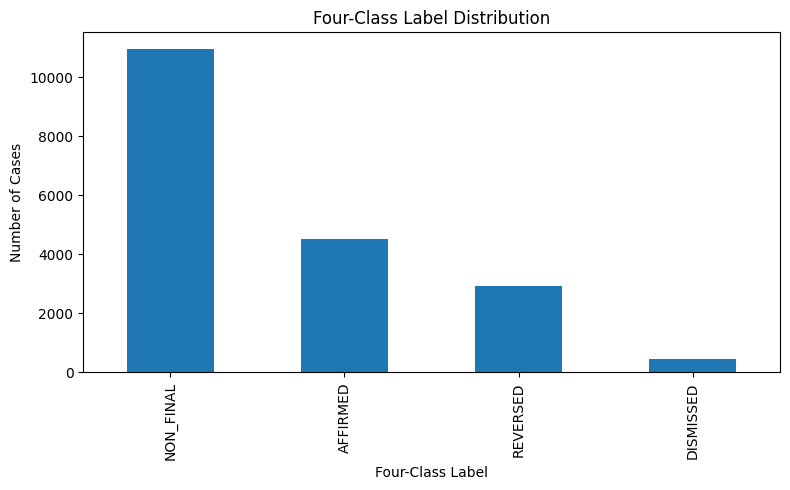


=== Four-Class Label vs Case Type ===

four_class_label               AFFIRMED  DISMISSED  NON_FINAL  REVERSED
Case_Type                                                              
Civil Procedure                    1670        203       2685      1268
Contract Law - Debt                 713         44       1329       580
Criminal Law                        546        125       3919       376
Property Law - Ejectment            740         28        805       476
Property Law - Execution Sale        74          1         78        58
Torts                               100         43       1816        54
Torts - Defamation                   84          2         60        92
Unclassified                        602         18        281        27


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# DISTRIBUTION
# ------------------------------------------------------------
print("\n=== VERDICT CATEGORY DISTRIBUTION ===\n")
df = engineer_four_class_labels(df, verdict_col='Verdict')
print(df['four_class_label'].value_counts())

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
df['four_class_label'].value_counts().plot(kind='bar')
plt.title("Four-Class Label Distribution")
plt.xlabel("Four-Class Label")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# VERDICT CATEGORY vs CASE TYPE
# ------------------------------------------------------------
print("\n=== Four-Class Label vs Case Type ===\n")
print(pd.crosstab(df['Case_Type'], df['four_class_label']))

In [13]:
# ============================================================
# STEP 2 → STEP 5 : TRAIN / TEST + NLP PIPELINE + TRAIN + EVALUATE
# ============================================================

import re
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# ------------------------------------------------------------
# 1. Prepare X and y (Leakage-safe)
# ------------------------------------------------------------

X = df[['Case_Text','Case_Type','Sub_Type','Court','Year']]
y = df['four_class_label']

# ------------------------------------------------------------
# 2. Train / Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 3. NLP + Metadata Preprocessing Pipeline
# ------------------------------------------------------------

text_vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,3),
    stop_words='english'
)

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_vectorizer, 'Case_Text'),
        ('meta', OneHotEncoder(handle_unknown='ignore'),
         ['Case_Type','Sub_Type','Court','Year'])
    ]
)

model = Pipeline([
    ('prep', preprocessor),
    (('clf', LogisticRegression(max_iter=500, class_weight='balanced')))
])

# ------------------------------------------------------------
# 4. Train the Model
# ------------------------------------------------------------

print("\nTraining model...")
model.fit(X_train, y_train)

# ------------------------------------------------------------
# 5. Evaluate the Model
# ------------------------------------------------------------

print("\nEvaluating model...")
pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

acc = accuracy_score(y_test, pred)
print(f"Accuracy: {acc*100:.2f}%")

# ------------------------------------------------------------
# 6. Cross Validation (research quality check)
# ------------------------------------------------------------

print("\nRunning 5-Fold Cross Validation...")
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"CV Mean Accuracy: {cv_scores.mean()*100:.2f}%")

# ------------------------------------------------------------
# 7. Save the Model
# ------------------------------------------------------------

#joblib.dump(model, "legal_verdict_model.pkl")
#print("\nModel saved as legal_verdict_model.pkl")

Train shape: (15117, 5)
Test shape : (3780, 5)

Training model...

Evaluating model...

Classification Report:

              precision    recall  f1-score   support

    AFFIRMED       0.87      0.95      0.91       906
   DISMISSED       0.41      0.65      0.50        93
   NON_FINAL       0.97      0.83      0.89      2195
    REVERSED       0.68      0.90      0.78       586

    accuracy                           0.86      3780
   macro avg       0.73      0.83      0.77      3780
weighted avg       0.89      0.86      0.87      3780

Accuracy: 86.38%

Running 5-Fold Cross Validation...
CV Mean Accuracy: 54.66%


In [14]:
# ============================================================
# STEP 2 → STEP 5 : PURE NLP PIPELINE (TEXT ONLY)
# Train / Test + TF-IDF + Logistic Regression + CV
# ============================================================

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# ------------------------------------------------------------
# 1. Prepare X and y  (STRICTLY TEXT ONLY — NO METADATA)
# ------------------------------------------------------------

X = df['Case_Text']              # Series, not DataFrame
y = df['four_class_label']

# ------------------------------------------------------------
# 2. Train / Test Split (stratified)
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 3. NLP Pipeline (TF-IDF → Logistic Regression)
# ------------------------------------------------------------

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,3),
        stop_words='english',
        min_df=3,
        max_df=0.9
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=None
    ))
])

# ------------------------------------------------------------
# 4. Train
# ------------------------------------------------------------

print("\nTraining model...")
model.fit(X_train, y_train)

# ------------------------------------------------------------
# 5. Evaluate on Test Set
# ------------------------------------------------------------

print("\nEvaluating model...")
pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

acc = accuracy_score(y_test, pred)
print(f"Test Accuracy: {acc*100:.2f}%")

# ------------------------------------------------------------
# 6. 5-Fold Cross Validation (REAL performance)
# ------------------------------------------------------------

print("\nRunning 5-Fold Cross Validation...")
cv_scores = cross_val_score(model, X, y, cv=5, n_jobs=-1)

print(f"CV Scores: {[round(s*100,2) for s in cv_scores]}")
print(f"CV Mean Accuracy: {cv_scores.mean()*100:.2f}%")

# ------------------------------------------------------------
# 7. Save the trained NLP model
# ------------------------------------------------------------

#joblib.dump(model, "legal_verdict_nlp_model.pkl")
#print("\nModel saved as: legal_verdict_nlp_model.pkl")

Train shape: (15117,)
Test shape : (3780,)

Training model...

Evaluating model...

Classification Report:

              precision    recall  f1-score   support

    AFFIRMED       0.88      0.94      0.91       906
   DISMISSED       0.44      0.67      0.53        93
   NON_FINAL       0.97      0.84      0.90      2195
    REVERSED       0.69      0.90      0.78       586

    accuracy                           0.87      3780
   macro avg       0.74      0.84      0.78      3780
weighted avg       0.89      0.87      0.87      3780

Test Accuracy: 86.90%

Running 5-Fold Cross Validation...
CV Scores: [np.float64(61.35), np.float64(68.84), np.float64(89.52), np.float64(81.56), np.float64(82.67)]
CV Mean Accuracy: 76.79%


Confusion Matrix:

[[ 851    5   26   24]
 [   4   62   23    4]
 [  75   67 1845  208]
 [  35    8   16  527]]


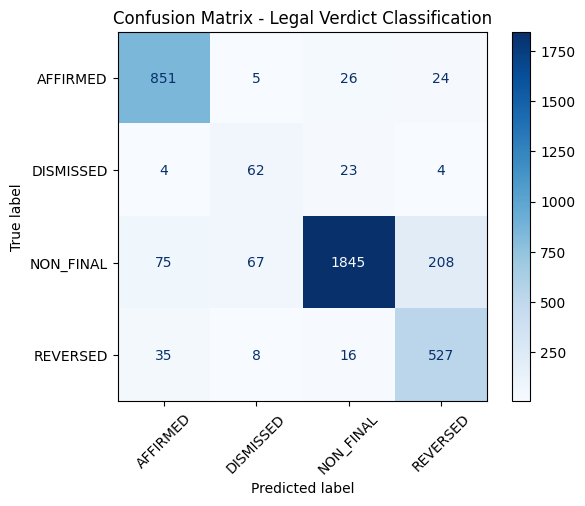

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# predictions (you already have this)
y_pred = model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print("Confusion Matrix:\n")
print(cm)

# optional: visual plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Legal Verdict Classification")
plt.show()

Train size: (15117,)
Test size : (3780,)

Before SMOTE:
 four_class_label
NON_FINAL    8778
AFFIRMED     3623
REVERSED     2345
DISMISSED     371
Name: count, dtype: int64

After SMOTE:
 four_class_label
REVERSED     8778
AFFIRMED     8778
NON_FINAL    8778
DISMISSED    8778
Name: count, dtype: int64

Training model...

Classification Report:

              precision    recall  f1-score   support

    AFFIRMED       0.89      0.95      0.92       906
   DISMISSED       0.50      0.68      0.58        93
   NON_FINAL       0.96      0.86      0.91      2195
    REVERSED       0.72      0.88      0.79       586

    accuracy                           0.88      3780
   macro avg       0.77      0.84      0.80      3780
weighted avg       0.89      0.88      0.89      3780


Test Accuracy: 88.20%

Confusion Matrix:

[[ 858    2   26   20]
 [   4   63   24    2]
 [  69   52 1897  177]
 [  31    8   31  516]]


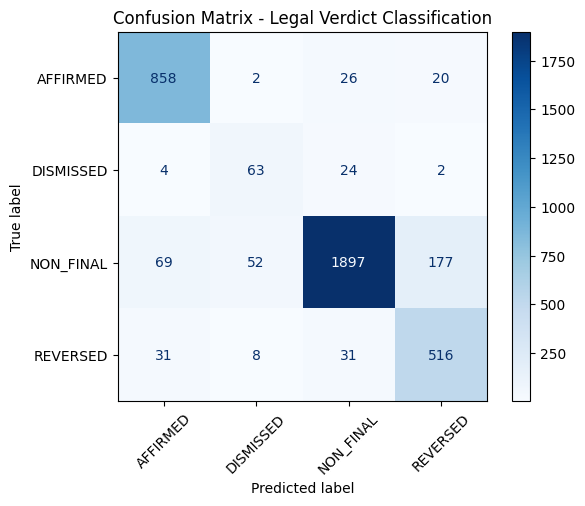

In [16]:
# ============================================================
# SMOTE + NLP + ML PIPELINE + CONFUSION MATRIX (ONE CELL)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

# -----------------------------
# 1. INPUT DATA
# -----------------------------
X_text = df["Case_Text"]
y = df["four_class_label"]

# -----------------------------
# 2. TRAIN / TEST SPLIT
# -----------------------------
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train_text.shape)
print("Test size :", X_test_text.shape)

# -----------------------------
# 3. TF-IDF VECTORIZATION
# -----------------------------
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

# -----------------------------
# 4. APPLY SMOTE (ONLY TRAIN DATA)
# -----------------------------
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_vec,
    y_train
)

print("\nBefore SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_balanced).value_counts())

# -----------------------------
# 5. TRAIN MODEL
# -----------------------------
model = LogisticRegression(max_iter=500, class_weight="balanced")

print("\nTraining model...")
model.fit(X_train_balanced, y_train_balanced)

# -----------------------------
# 6. PREDICTION
# -----------------------------
y_pred = model.predict(X_test_vec)

# -----------------------------
# 7. EVALUATION
# -----------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc * 100:.2f}%")

# -----------------------------
# 8. CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print("\nConfusion Matrix:\n")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Legal Verdict Classification")
plt.show()